# Where we are

**The one question this whole project has become:** AVES — a model trained on *general* animal
audio — beats our model trained specifically on zebra finches. **Why?** If we can name the reason,
we know how to build something better than AVES.

**Latest (Sep 25): we found the lever.** run16 — the same recipe, just using the 4 GPUs we were
already paying for — jumped past both our older models and is now within noise of every AVES
version. The missing ingredient was **compute**: how much audio the model processes per training step.

Five sections, each short:

1. **The scoreboard** — who's winning, and is the gap real?
2. **The suspects** — every explanation we've tested
3. **The lever: compute** — why run16 moved when nothing else did
4. **What run16 looks like from the inside** — its training curve
5. **What's next** — run17, already running

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

A = Path.home() / "zf_labelset/zf_detection_dataset_v1/analysis"
VAR   = json.loads((A / "aves_variants_calltype.json").read_text())   # run11 + six AVES checkpoints
R15   = json.loads((A / "run15_calltype.json").read_text())           # run15 on the same probe
R16   = json.loads((A / "run16_compute4x_calltype.json").read_text()) # run16 on the same probe
BOOT  = json.loads((A / "run16_bootstrap.json").read_text())          # paired intervals, run16 vs all
COMP  = json.loads((A / "compute_budget.json").read_text())           # run11 + AVES training budgets
COMP15 = json.loads((A / "run15_compute.json").read_text())           # run15 + run16 measured

# two roles only, validated with the dataviz palette checker (CVD dE 24.7, contrast >= 3:1)
OURS, AVES = "#eb6834", "#2a78d6"
INK, INK2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e5e0"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2,
                     "ytick.color": INK, "text.color": INK, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("loaded 6 result files")

loaded 6 result files


---
## 1. The scoreboard

Task: tell apart **11 zebra finch call types**. We freeze each model, read out its internal
representation, and train only a simple classifier on top. Tested on birds the classifier never
saw during training. Higher is better.

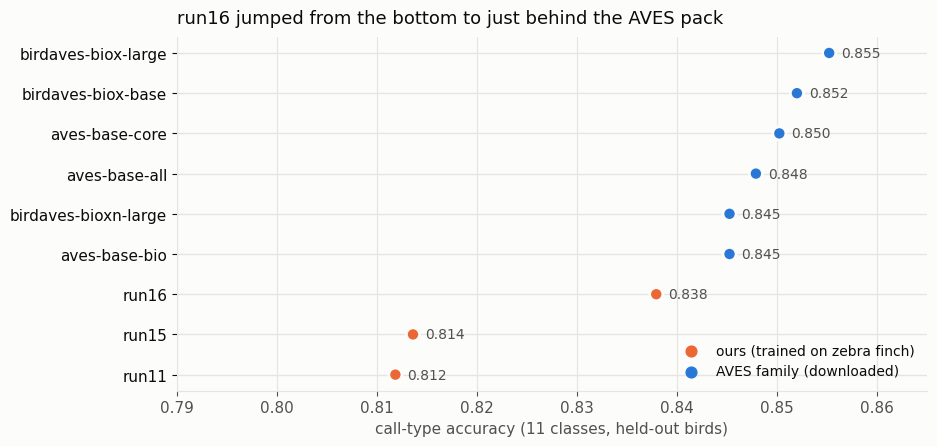

In [2]:
acc = {m: VAR["models"][m]["best_11"]["acc"] for m in VAR["models"]}
acc["run15"] = R15["acc11"]
acc["run16"] = R16["acc11"]
ours = {"run11", "run15", "run16"}
order = sorted(acc, key=acc.get)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(order))
# full-width row guides, NOT stems: the axis starts at 0.79, so a stem from there would read
# as a bar length and exaggerate the gap. Only the dot position carries meaning.
ax.hlines(y, 0.79, 0.865, color=GRID, lw=1, zorder=1)
ax.scatter([acc[m] for m in order], y, s=90, zorder=3,
           color=[OURS if m in ours else AVES for m in order],
           edgecolors=SURFACE, linewidths=2)
for yi, m in zip(y, order):
    ax.text(acc[m] + 0.0012, yi, f"{acc[m]:.3f}", va="center", fontsize=10, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlim(0.79, 0.865)
ax.set_xlabel("call-type accuracy (11 classes, held-out birds)")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.scatter([], [], color=OURS, s=60, label="ours (trained on zebra finch)")
ax.scatter([], [], color=AVES, s=60, label="AVES family (downloaded)")
ax.legend(frameon=False, loc="lower right", fontsize=10)
ax.set_title("run16 jumped from the bottom to just behind the AVES pack", loc="left", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

**Is the gap real, or noise?** With only 48 birds, small differences can be luck. The honest
check resamples the *birds* 2,000 times and asks whether the gap ever crosses zero.

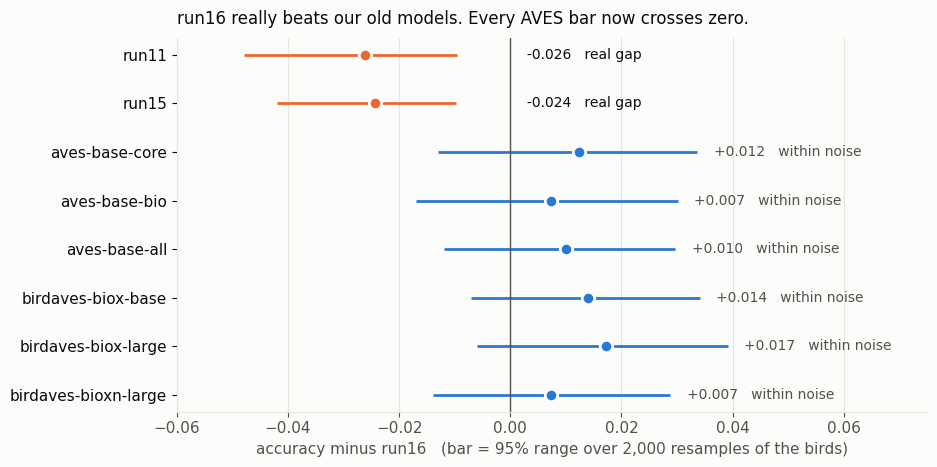

In [3]:
V = BOOT["vs"]["run16_compute4x"]          # stores run16 minus X
rows = ["run11", "run15_combined"] + [m for m in VAR["models"] if m != "run11"]
# flip so the chart reads "X minus run16": right of zero = X is better than run16
d  = [-V[k]["delta"] for k in rows]
lo = [-V[k]["hi"] for k in rows]
hi = [-V[k]["lo"] for k in rows]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(rows))[::-1]
for yi, k, a, b, c in zip(y, rows, lo, hi, d):
    col = OURS if k.startswith("run") else AVES
    ax.hlines(yi, a, b, color=col, lw=2)
    ax.scatter(c, yi, s=80, color=col, zorder=3, edgecolors=SURFACE, linewidths=2)
    real = V[k]["resolved"]
    ax.text(max(b, 0) + 0.003, yi, f"{c:+.3f}   " + ("real gap" if real else "within noise"),
            va="center", fontsize=10, color=INK if real else INK2)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(y); ax.set_yticklabels([k.replace("_combined", "") for k in rows])
ax.set_xlim(-0.06, 0.075)
ax.set_xlabel("accuracy minus run16   (bar = 95% range over 2,000 resamples of the birds)")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title("run16 really beats our old models. Every AVES bar now crosses zero.",
             loc="left", fontsize=12, pad=10)
plt.tight_layout(); plt.show()

**How to read it:** a bar that crosses the zero line means "can't tell these two apart with 48
birds". Before run16, *every* AVES bar sat clear of zero. Now none do.

**What it does NOT say:** that we've tied AVES. Every AVES dot is still to the right — ahead by
0.7 to 1.7 points — and a gap that small is simply too fine for 48 birds to resolve. The gain is
also not from cherry-picking a layer: at layer 3 (the layer run11 and run15 use) run16 still wins
by a real margin, and all 12 of run16's layers beat run15's best one.

**Also worth knowing:** `aves-base-bio` — the "AVES" we quoted in every past comparison — is tied
for the *weakest* of the six. So the old headline gap was the most flattering version for us.

---
## 2. The suspects

Our model and AVES are the **exact same architecture** — same 94.37M parameters, same layers. So
the gap has to come from *how* each was trained. Each row is one difference between the two
recipes, and what happened when we changed ours to match.

In [4]:
b = {"delta": -V["run11"]["delta"] + V["run15_combined"]["delta"]}   # run15 minus run11, via run16
tbl = f"""
| suspect | how we tested it | verdict |
|---|---|---|
| **architecture** | compared parameter counts and weight names | ❌ ruled out — identical model |
| **more / more varied audio** | run15: 116 h → {COMP15['run15']['corpus_hours']:.0f} h, adding general sound (FSD50K) | ❌ ruled out at our compute — {-b['delta']:+.4f}, within noise |
| **bigger label vocabulary** (k=100 → 200) | run15, same run | ❌ ruled out at our compute |
| **better training labels** ("iteration 2") | run12, run13, run14 | ❌ ruled out at our compute — none beat run11 |
| **start from AVES, keep training** (DAPT) | DAPT rounds 1 & 2 | ❌ worse on held-out recordings |
| **total training compute** | run16: 4× the audio per step, nothing else changed | ✅ **the lever** — {V['run15_combined']['delta']:+.4f} over run15, a real gap |
"""
display(Markdown(tbl))


| suspect | how we tested it | verdict |
|---|---|---|
| **architecture** | compared parameter counts and weight names | ❌ ruled out — identical model |
| **more / more varied audio** | run15: 116 h → 224 h, adding general sound (FSD50K) | ❌ ruled out at our compute — +0.0018, within noise |
| **bigger label vocabulary** (k=100 → 200) | run15, same run | ❌ ruled out at our compute |
| **better training labels** ("iteration 2") | run12, run13, run14 | ❌ ruled out at our compute — none beat run11 |
| **start from AVES, keep training** (DAPT) | DAPT rounds 1 & 2 | ❌ worse on held-out recordings |
| **total training compute** | run16: 4× the audio per step, nothing else changed | ✅ **the lever** — +0.0243 over run15, a real gap |


Notice the pattern: every ❌ says **"at our compute."** Those experiments changed *what* the model
learned from while keeping *how much* fixed. The first time we changed the amount, the number moved.

---
## 3. The lever: compute

"Compute" here means **total hours of audio the model processed during training** — corpus size
times how many passes it made.

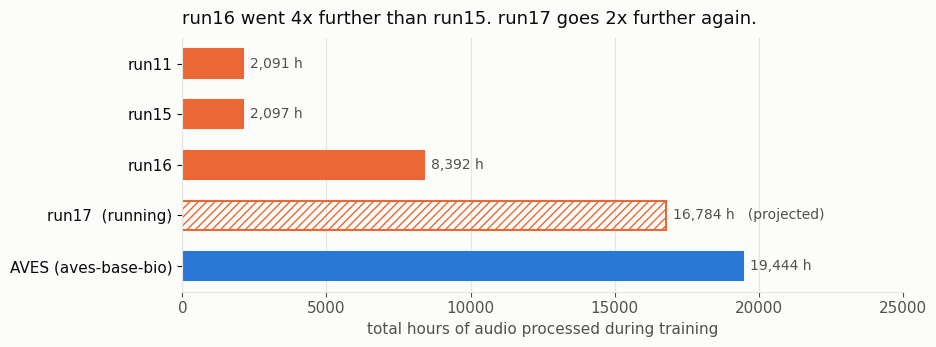

In [5]:
bars = [("run11",              COMP["run11"]["audio_seconds_per_update"] * COMP["run11"]["updates"] / 3600, OURS, False),
        ("run15",              COMP15["run15"]["total_audio_hours"], OURS, False),
        ("run16",              COMP15["run16"]["total_audio_hours"], OURS, False),
        ("run17  (running)",   2 * COMP15["run16"]["total_audio_hours"], OURS, True),
        ("AVES (aves-base-bio)", COMP["aves"]["audio_seconds_per_update"] * COMP["aves"]["updates"] / 3600, AVES, False)]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
y = np.arange(len(bars))[::-1]
for yi, (name, h, col, planned) in zip(y, bars):
    ax.barh(yi, h, height=0.56, color="none" if planned else col, edgecolor=col,
            hatch="////" if planned else None, lw=1.5)
    ax.text(h + 250, yi, f"{h:,.0f} h" + ("   (projected)" if planned else ""),
            va="center", fontsize=10, color=INK2)
ax.set_yticks(y); ax.set_yticklabels([b[0] for b in bars])
ax.set_xlim(0, 25000)
ax.set_xlabel("total hours of audio processed during training")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title("run16 went 4x further than run15. run17 goes 2x further again.",
             loc="left", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

In [6]:
r11, av, r15, r16 = COMP["run11"], COMP["aves"], COMP15["run15"], COMP15["run16"]
print(f"{'':22}{'run11':>10}{'run15':>10}{'run16':>10}{'AVES':>10}")
print(f"{'audio per step (s)':22}{r11['audio_seconds_per_update']:>10.1f}{r15['audio_seconds_per_update']:>10.1f}{r16['audio_seconds_per_update']:>10.1f}{av['audio_seconds_per_update']:>10.1f}")
print(f"{'training steps':22}{r11['updates']:>10,}{r15['updates']:>10,}{r16['updates']:>10,}{av['updates']:>10,}")
print(f"{'GPUs actually used':22}{r11['world_size']:>10}{r15['world_size_realised']:>10}{r16['world_size_realised']:>10}{av['world_size']:>10}")
print(f"{'gradient accumulation':22}{r11['update_freq']:>10}{1:>10}{1:>10}{av['update_freq']:>10}")

                           run11     run15     run16      AVES
audio per step (s)          80.3      80.5     322.2     700.0
training steps            93,750    93,750    93,750   100,000
GPUs actually used             1         1         4         1
gradient accumulation          1         1         1         8


**Read the last two rows.** AVES used **one GPU** too — it got its big batch by *accumulating*
8 batches before each update. Every one of our runs until run16 **requested four GPUs and used
one** (a job-script setting, `--ntasks=1`). run16 fixed that setting and changed nothing else.

It is still only at ~43% of AVES's total. run17 adds 2× accumulation on top — the same trick AVES
used — to reach ~92% of AVES's audio per step.

---
## 4. What run16 looks like from the inside

During training the model plays a fill-in-the-blank game: hide some audio, guess the hidden
sound's label. The **loss** is how wrong its guesses are (lower = better). run15 and run16 play the
same game with the same 200 labels, so their losses are directly comparable. At every point in
training, run16 is better at it:

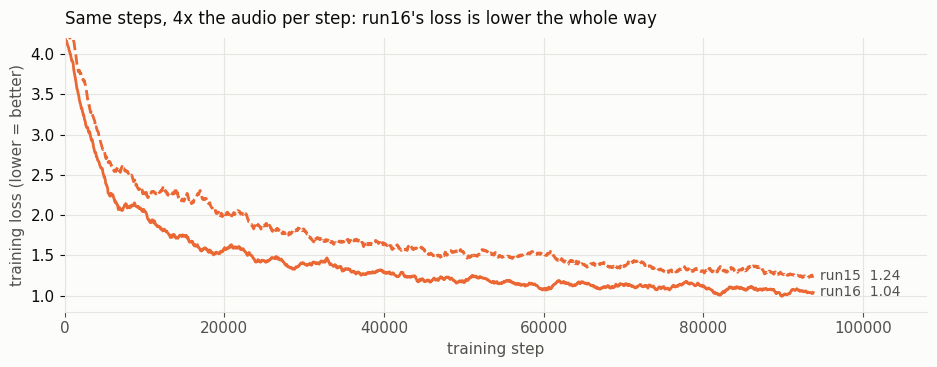

In [7]:
import glob, pandas as pd
M = Path.home() / "Desktop/vocalizations_lab/savio_artifacts/metrics"

def stitch(run):
    """One curve per run. Each preemption restarts from the last checkpoint and re-runs some steps
    in a NEW log file; where two files overlap, the later attempt is the one that continued."""
    parts = [pd.read_csv(f).dropna(subset=["train_loss_step"]).sort_values("step")
             for f in sorted(glob.glob(str(M / run / "*.csv")))]
    keep = [p[p.step < parts[i + 1].step.min()] if i + 1 < len(parts) else p
            for i, p in enumerate(parts)]
    return pd.concat(keep)

fig, ax = plt.subplots(figsize=(9.5, 3.8))
for run, ls in [("run15", "--"), ("run16", "-")]:
    d = stitch(run)
    sm = d["train_loss_step"].rolling(40, min_periods=10, center=True).mean()
    ax.plot(d["step"], sm, color=OURS, ls=ls, lw=2)
    ax.text(d["step"].iloc[-1] + 800, sm.dropna().iloc[-1], f"{run}  {sm.dropna().iloc[-1]:.2f}",
            va="center", fontsize=10, color=INK2)
ax.set_xlim(0, 108000); ax.set_ylim(0.8, 4.2)
ax.set_xlabel("training step"); ax.set_ylabel("training loss (lower = better)")
ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title("Same steps, 4x the audio per step: run16's loss is lower the whole way",
             loc="left", fontsize=12, pad=10)
plt.tight_layout(); plt.show()

*Why loss and not "accuracy"?* The training log also records a masked-accuracy number, but it
turned out to be a running average since the job last started. It lags, and it jumps every time a
preempted job restarts, so it can't be compared across runs. The loss is recorded fresh every step.

---
## 4b. Does run16's gain hold beyond call types?

Two other tests. **Detection** asks whether a moment of audio contains a call. **Holdouts** use
recordings the model never heard in training: BirdPark (a different colony) and chicks (different
birds, different calls).

In [8]:
DET = json.loads((A / "detection_variants.json").read_text())["precommit"]
CH  = json.loads((A / "chick_holdout_variants.json").read_text())
DB  = json.loads((A / "detection_variants.json").read_text())["bootstrap"]["run16_compute4x"]
CB  = CH["bootstrap"]["run16_compute4x_vs_run11"]["be_lt_auc"]
j = lambda m: DET[m]["joint"]
aves_bp = [j(m)["bp"]["auc"] for m in VAR["models"] if m != "run11"]
verdict = lambda b: "run16 better, real" if b["lo"] > 0 else ("run16 worse, real" if b["hi"] < 0 else "within noise")
tbl = f"""
| test | run11 | run15 | run16 | AVES (range) | run16 vs run11 |
|---|---|---|---|---|---|
| detection, zebra finch (AUC) | {j('run11')['zf']['auc']:.4f} | {j('run15_combined')['zf']['auc']:.4f} | **{j('run16_compute4x')['zf']['auc']:.4f}** | {min(j(m)['zf']['auc'] for m in VAR['models'] if m != 'run11'):.4f}–{max(j(m)['zf']['auc'] for m in VAR['models'] if m != 'run11'):.4f} | {verdict(DB['indist_auc_block1500'])} |
| detection, BirdPark holdout (AUC) | {j('run11')['bp']['auc']:.4f} | {j('run15_combined')['bp']['auc']:.4f} | {j('run16_compute4x')['bp']['auc']:.4f} | {min(aves_bp):.4f}–{max(aves_bp):.4f} | {verdict(DB['bp_auc_block1500'])} |
| chick holdout, Be vs LT (AUC) | {CH['precommit']['run11']['auc']:.4f} | {CH['precommit']['run15_combined']['auc']:.4f} | {CH['precommit']['run16_compute4x']['auc']:.4f} | — | {verdict(CB)} |
"""
display(Markdown(tbl))


| test | run11 | run15 | run16 | AVES (range) | run16 vs run11 |
|---|---|---|---|---|---|
| detection, zebra finch (AUC) | 0.9687 | 0.9696 | **0.9718** | 0.9667–0.9724 | run16 better, real |
| detection, BirdPark holdout (AUC) | 0.8648 | 0.7476 | 0.8085 | 0.8665–0.8994 | within noise |
| chick holdout, Be vs LT (AUC) | 0.9858 | 0.9940 | 0.9936 | — | within noise |


**Plain reading.** On zebra finch detection run16 is the best same-size model we have. On BirdPark
it is *behind* run11 on the number, but BirdPark is only two minutes of audio, so "within noise" is
all the data can say. It did improve over run15 there, so compute helped on BirdPark too; the drop
relative to run11 came in with run15's changes (the bigger mixed corpus and the 200-label vocabulary).
The chick test is at its ceiling for every model, so it only catches a model getting *worse*,
and run16 didn't.

---
## 5. What's next

| # | who | what | status |
|---|---|---|---|
| 1 | me | **run17** = run16 + 2× accumulation (~92% of AVES per step) | **running** — Savio job 39268321, ~11 h of GPU time |
| 2 | me | score run17 on this scoreboard | when it finishes: does it move again, or has compute run out? |
| 3 | me | score run17 on detection + both holdouts too | same tests as section 4b |
| 4 | **you** | keep Savio logged in (`ssh -MNf savio-login`) | the login drops when the laptop sleeps; results wait until it's back |

**Checked before launching run17:** a 2-minute test run (job 39267771) confirmed accumulation
really works: 300 batches, 150 updates. My first attempt had a missing import that killed the test
in 10 seconds. That's why the test exists: it caught the bug before it could cost an 11-hour run.

---
## Side quest, done: clustering when nobody labelled the data

For bats with no labels: **don't** judge a clustering by how tight its groups are (silhouette etc.
— those rank models *backwards*). Judge it by whether the groups **reappear in individuals you held
out**. Full walkthrough with plots: `04_clustering_without_labels.ipynb`.